# HDT 4: Regresión Logística y Métricas

**Ciencia de Datos, Sección A** · Asignada: jueves 17 de septiembre · **Entrega: martes 22 de septiembre, 23:59**

**Nombre:** _Jonatan Aguilar (20240565)_

Completar las celdas marcadas con `# ¿Qué va aquí?`. Cada ejercicio incluye una verificación comentada: descomentar para comprobar el resultado. Antes de entregar: **Kernel → Restart & Run All** (un notebook que no corre de arriba a abajo pierde 0.5 pts).

AI: resolver sin AI. Si se usó para entender un concepto, anotarlo en la bitácora del final (no penaliza).

## Setup

Dependencias: `pip install numpy pandas matplotlib scikit-learn`. Todo es determinista (semilla fija y split fijo): las verificaciones son exactas.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

AZUL, ROJO, GRIS, LINEA = "#3A6EA5", "#B04A2E", "#75808E", "#E0E4EA"

def eje_limpio(ax):
    ax.grid(color=LINEA, lw=0.6, alpha=0.7)
    ax.spines[["top", "right"]].set_visible(False)

## Los datos

Una empresa de internet residencial quiere saber qué clientes van a cancelar. Historial de 1,200 clientes: `mensualidad` (quetzales al mes), `meses` (antigüedad como cliente), `reclamos` (en el último año) y `cancelo` (1 = canceló el servicio). Es el mismo tipo de problema que la mora de la sesión 14, con otro negocio.

La celda genera los datos completa; no hay nada que llenar aquí.

In [14]:
rng = np.random.default_rng(9)
n = 1200
mensualidad = rng.normal(350, 90, n).clip(150, 700).round(0)
meses = rng.integers(1, 61, n)
reclamos = np.minimum(rng.poisson(0.8, n), 6)

riesgo = -1.1 + 0.006 * (mensualidad - 350) - 0.06 * meses + 0.9 * reclamos
cancelo = (rng.random(n) < 1 / (1 + np.exp(-riesgo))).astype(int)

df = pd.DataFrame({"mensualidad": mensualidad, "meses": meses,
                   "reclamos": reclamos, "cancelo": cancelo})
print("clientes:", len(df), "| fracción que canceló:", df["cancelo"].mean().round(3))
df.head()

clientes: 1200 | fracción que canceló: 0.169


,mensualidad,meses,reclamos,cancelo
0,278.0,48,0,0
1,372.0,46,0,0
2,201.0,7,0,0
3,409.0,24,2,0
4,453.0,48,3,0


## Parte A · El modelo (0.5 pt)

Regresión logística como en la sesión 14: una suma con pesos que la sigmoide convierte en una probabilidad entre 0 y 1.

### Ejercicio 1 (0.15): entrenar y leer los pesos

Entrenar el pipeline de clase (StandardScaler + LogisticRegression) sobre el split dado. Extraer el punto de partida `b` y los tres `pesos`, e imprimirlos con el nombre de su columna. Responder en un comentario: ¿qué columna protege más contra la cancelación?

In [15]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

columnas = ["mensualidad", "meses", "reclamos"]
X_train, X_test, y_train, y_test = train_test_split(
    df[columnas], df["cancelo"], test_size=0.3, random_state=42)

modelo = make_pipeline(StandardScaler(), LogisticRegression())
modelo.fit(X_train, y_train)
b = modelo[1].intercept_[0]
pesos = modelo[1].coef_[0]

# imprimir b y cada peso con su columna

print(f"Intercepto (b): {b:.2f}")
for col, peso in zip(columnas, pesos):
    print(f"{col}: {peso:.2f}")

# Verificación (descomentar):
assert round(b, 2) == -2.29
assert [round(w, 2) for w in pesos] == [0.64, -1.35, 0.62]

Intercepto (b): -2.29
mensualidad: 0.64
meses: -1.35
reclamos: 0.62


### Ejercicio 2 (0.20): un cliente, a mano

Cliente nuevo: paga Q380, lleva 4 meses, puso 2 reclamos. Calcular su probabilidad de cancelar sin `predict_proba`: (a) escalar cada valor con `escalador.mean_` y `escalador.scale_`, (b) armar la suma `b + w1 * x1 + w2 * x2 + w3 * x3`, (c) pasarla por la sigmoide. Luego comparar contra `modelo.predict_proba`: deben coincidir.

In [16]:
def sigmoide(z):
    return 1 / (1 + np.exp(-z))

cliente = pd.DataFrame({"mensualidad": [380.0], "meses": [4], "reclamos": [2]})

# el escalador es modelo[0]; sus medias y desviaciones: .mean_ y .scale_

# Escalar el cliente: (valor - media) / desviacion_estandar
cliente_escalado = (cliente - modelo[0].mean_) / modelo[0].scale_

z = b + np.sum(cliente_escalado.values * pesos)
p_mano = sigmoide(z)
p_sklearn = modelo.predict_proba(cliente)[0][1]

# Verificación (descomentar):
assert round(p_mano, 3) == round(p_sklearn, 3) == 0.721

### Ejercicio 3 (0.15): equivocarse con confianza cuesta caro

El castigo de una predicción es `-log(p asignada a lo que realmente pasó)`. (a) Calcular el castigo para un cliente que sí canceló al que el modelo le dijo 0.99, 0.9, 0.5, 0.1 y 0.01. (b) Con `log_loss`, el castigo promedio del modelo en test contra el de un modelo tibio que le dice 0.5 a todo el mundo.

In [17]:
from sklearn.metrics import log_loss

p_dijo = np.array([0.99, 0.9, 0.5, 0.1, 0.01])
castigos = -np.log(p_dijo)

prob = modelo.predict_proba(X_test)[:, 1]
castigo_modelo = log_loss(y_test, prob)
castigo_tibio = log_loss(y_test, np.full(len(y_test), 0.5))

# Verificación (descomentar):
assert round(castigos[-1], 1) == 4.6
assert round(castigo_modelo, 3) == 0.347 and round(castigo_tibio, 3) == 0.693

## Parte B · Métricas como conteos (0.5 pt)

Solo el 17% de los clientes cancela. Con clases desbalanceadas, contar aciertos engaña; contar por tipo de acierto y de error, no.

### Ejercicio 4 (0.15): el modelo perezoso

(a) La accuracy de un modelo perezoso que dice "nadie cancela". (b) La accuracy del modelo real con umbral 0.5. Ver qué tan poca ventaja aparenta tener el modelo cuando se mide con la métrica equivocada.

In [41]:
pred = (prob >= 0.5).astype(int)

acc_perezoso = (y_test == 0).mean()
acc_modelo = (y_test == pred).mean()

print(f"accuracy perezoso: {acc_perezoso:.3f}")
print(f"accuracy modelo: {acc_modelo:.3f}")

# Verificación (descomentar):
assert round(acc_perezoso, 3) == 0.833
assert round(acc_modelo, 3) == 0.869

accuracy perezoso: 0.833
accuracy modelo: 0.869


### Ejercicio 5 (0.20): los cuatro conteos

Con umbral 0.5, calcular los cuatro conteos y armar la tabla 2 x 2 como en clase (filas: canceló / se quedó; columnas: el modelo dijo cancela / dijo se queda).

In [29]:
TP = ((pred == 1) & (y_test == 1)).sum()
FP = ((pred == 1) & (y_test == 0)).sum()
FN = ((pred == 0) & (y_test == 1)).sum()
TN = ((pred == 0) & (y_test == 0)).sum()

tabla = pd.DataFrame({
    "modelo dijo cancela": [TP, FP],
    "modelo dijo se queda": [FN, TN]
}, index=["canceló", "se quedó"])
print(tabla)

# Verificación (descomentar):
assert [TP, FP, FN, TN] == [22, 9, 38, 291]
assert TP + FP + FN + TN == len(y_test)

          modelo dijo cancela  modelo dijo se queda
canceló                    22                    38
se quedó                    9                   291


### Ejercicio 6 (0.15): las dos preguntas del negocio

Desde los conteos, sin sklearn: precision (de las alertas, ¿cuántas eran canceladores de verdad?) y recall (de los que cancelaron, ¿a cuántos alcanzó a avisar el modelo?). Imprimir las dos frases completas con sus números, como en la sesión 14.

In [31]:
precision = TP / (TP + FP)
recall = TP / (TP + FN)

print(f"alertas: {TP + FP}, de ellas canceladores: {TP} -> precision = {precision:.2f}")
print(f"canceladores reales: {TP + FN}, avisados: {TP} -> recall = {recall:.2f}")

# Verificación (descomentar):
assert round(precision, 2) == 0.71
assert round(recall, 2) == 0.37

alertas: 31, de ellas canceladores: 22 -> precision = 0.71
canceladores reales: 60, avisados: 22 -> recall = 0.37


## Parte C · Umbral, AUC y calibración (0.8 pt)

El 0.5 es un default, no una decisión. Y dos preguntas más profundas que cualquier umbral: ¿el modelo ordena bien?, ¿dice la verdad?

### Ejercicio 7 (0.20): mover el umbral

Para cada umbral en [0.2, 0.35, 0.5, 0.65]: recalcular predicciones, contar alertas, precision y recall, imprimir la línea y guardar el número de alertas en `alertas_por_umbral`. Esta tabla es el insumo de la parte D.

In [33]:
alertas_por_umbral = []
for umbral in [0.2, 0.35, 0.5, 0.65]:
    pred_u = (prob >= umbral).astype(int)
    
    tp = ((pred_u == 1) & (y_test == 1)).sum()
    fp = ((pred_u == 1) & (y_test == 0)).sum()
    fn = ((pred_u == 0) & (y_test == 1)).sum()
    
    alertas = tp + fp
    prec_u = tp / alertas if alertas > 0 else 0
    rec_u = tp / (tp + fn)
    
    print(f"Umbral {umbral}: alertas={alertas} | precision={prec_u:.3f} | recall={rec_u:.3f}")
    
    alertas_por_umbral.append(alertas)

# Verificación (descomentar):
assert alertas_por_umbral == [116, 63, 31, 12]

Umbral 0.2: alertas=116 | precision=0.371 | recall=0.717
Umbral 0.35: alertas=63 | precision=0.508 | recall=0.533
Umbral 0.5: alertas=31 | precision=0.710 | recall=0.367
Umbral 0.65: alertas=12 | precision=0.667 | recall=0.133


### Ejercicio 8 (0.20): la curva completa

La misma idea, continua: para umbrales de 0.05 a 0.90 en pasos de 0.05, graficar precision (AZUL) y recall (ROJO) contra el umbral, con `eje_limpio`, leyenda y una línea vertical punteada en 0.5. Un vistazo a la figura debe bastar para ver el intercambio.

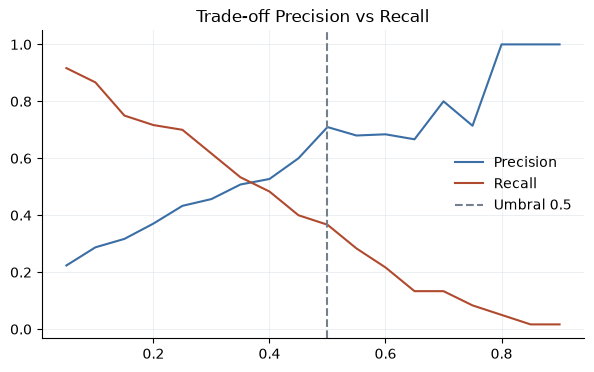

In [34]:
umbrales = np.arange(0.05, 0.91, 0.05)
precisiones = []
recalls = []

for u in umbrales:
    pred_u = (prob >= u).astype(int)
    tp = ((pred_u == 1) & (y_test == 1)).sum()
    fp = ((pred_u == 1) & (y_test == 0)).sum()
    fn = ((pred_u == 0) & (y_test == 1)).sum()
    
    prec = tp / (tp + fp) if (tp + fp) > 0 else 1
    rec = tp / (tp + fn)
    
    precisiones.append(prec)
    recalls.append(rec)

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(umbrales, precisiones, color=AZUL, label="Precision")
ax.plot(umbrales, recalls, color=ROJO, label="Recall")
ax.axvline(0.5, color=GRIS, ls="--", label="Umbral 0.5")
eje_limpio(ax)
ax.legend(frameon=False)
plt.title("Trade-off Precision vs Recall")
plt.show()

# Verificación (descomentar):
assert len(precisiones) == len(recalls) == len(umbrales) == 18

### Ejercicio 9 (0.20): AUC por pares

AUC sin fórmula, como en la sesión: tomar 5,000 canceladores al azar y 5,000 no canceladores al azar (con `rng_auc.choice`, en ese orden), y medir en qué fracción de los pares el cancelador recibió mayor probabilidad. Comparar contra `roc_auc_score`.

In [37]:
from sklearn.metrics import roc_auc_score

rng_auc = np.random.default_rng(7)

pos = prob[y_test == 1]
neg = prob[y_test == 0]

# luego, exactamente en este orden:
p_azar = rng_auc.choice(pos, 5000)
n_azar = rng_auc.choice(neg, 5000)

auc_pares = (p_azar > n_azar).mean()
auc_sklearn = roc_auc_score(y_test, prob)

# Verificación (descomentar):
assert round(auc_pares, 3) == 0.821
assert round(auc_sklearn, 3) == 0.822

### Ejercicio 10 (0.20): ¿dice la verdad?

Agrupar las probabilidades del test en cajones con `pd.cut` (bordes [0, 0.2, 0.4, 0.6, 0.8, 1.0]) y construir la tabla de calibración: por cajón, el promedio de lo que el modelo dijo, la fracción que de verdad canceló y el número de clientes.

In [40]:
grupos = pd.cut(prob, [0, 0.2, 0.4, 0.6, 0.8, 1.0])

calib = pd.DataFrame({"dijo": prob, "real": y_test}).groupby(grupos, observed=False).agg(
    dijo=("dijo", "mean"),
    real=("real", "mean"),
    clientes=("real", "count")
)

# Verificación (descomentar):
assert calib["clientes"].tolist() == [244, 61, 36, 16, 3]

## Parte D · Criterio (0.2 pt)

### Ejercicio 11 (0.20)

Dos preguntas, 2-3 líneas cada una, **citando los números obtenidos**:

**(a)** Una llamada de retención cuesta Q25; un cliente que se va sin aviso cuesta Q1,500. Con la tabla del ejercicio 7, ¿qué umbral conviene y por qué? (Basta comparar el costo total de dos o tres umbrales.)

**(b)** El gerente quiere presentar el modelo diciendo "acierta el 87% de las veces". Con los números de los ejercicios 4 y 6, explicar por qué ese argumento es débil y proponer el argumento honesto.

_(Responder editando esta celda)_

**Respuesta (a):** Conviene el umbral bajo (0.2). Perder a un cliente sin avisar cuesta Q1,500, mientras que hacer una llamada "desperdiciada" (Falso Positivo) solo cuesta Q25. Un umbral bajo atrapa casi todas las cancelaciones (alto Recall), y el costo de hacer las 116 llamadas (Q2,900) es mínimo comparado con perder clientes caros.

**Respuesta (b):** Decir que "acierta el 87%" es engañoso porque el 83.3% de la base NO cancela (el modelo perezoso del Ejercicio 4 acierta 83% sin hacer nada). El argumento honesto esta endocado en el Recall: "De los clientes que realmente se van a cancelar, el modelo logra identificar y avisarnos del 37% de ellos antes de que se vayan, con una precisión del 71%".

Es decir que de 100 clientes 

## Bitácora de AI (opcional, no penaliza)

Si se usó AI para entender algún concepto, anotar aquí qué se preguntó y qué se entendió. Si no se usó, escribir "No se usó".

- ...